In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/netflix_titles.csv')
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
release_year,8807.0,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0


In [ ]:
df.duplicated().sum()
print(df.duplicated().sum())

0


In [ ]:
df.isnull().sum()
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [ ]:
# 2. HIGH CARDINALITY: Fill with 'Unknown'
# We avoid the Mode here to prevent biasing the "Top Directors/Cast" charts.
df['director'] = df['director'].fillna('Unknown Director')
df['cast'] = df['cast'].fillna('Unknown Cast')

# 3. GEOGRAPHICAL & CATEGORICAL: Fill with Mode
# 'country' has a clear majority (usually USA), making Mode a safe statistical bet.
df['country'] = df['country'].fillna(df['country'].mode()[0])
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

# 4. DATA INTEGRITY: Duration Fix
# In the Netflix dataset, sometimes duration slips into the rating column.
# This code ensures duration is filled with the most common value.
df['duration'] = df['duration'].fillna(df['duration'].mode()[0])

# 5. TIME SERIES: Drop small nulls
# We drop the 10 rows with missing 'date_added' to keep our timeline analysis accurate.
df.dropna(subset=['date_added'], inplace=True)

# 6. FORMATTING: Convert date_added to Datetime objects
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())

print("\n--- Missing Values After Treatment ---")
print(df.isnull().sum())

# Preview the cleaned data
df.head()


--- Missing Values After Treatment ---
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown Cast,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown Director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown Director,Unknown Cast,United States,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown Director,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


/tmp/ipykernel_20920/2751713236.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', ax=axes[0], palette='Reds')
/tmp/ipykernel_20920/2751713236.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10.values, y=top_10.index, ax=axes[1], palette='viridis')
/tmp/ipykernel_20920/2751713236.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', ax=axes[2], order=df['rating'].value_counts().index[:10], palette='mako')


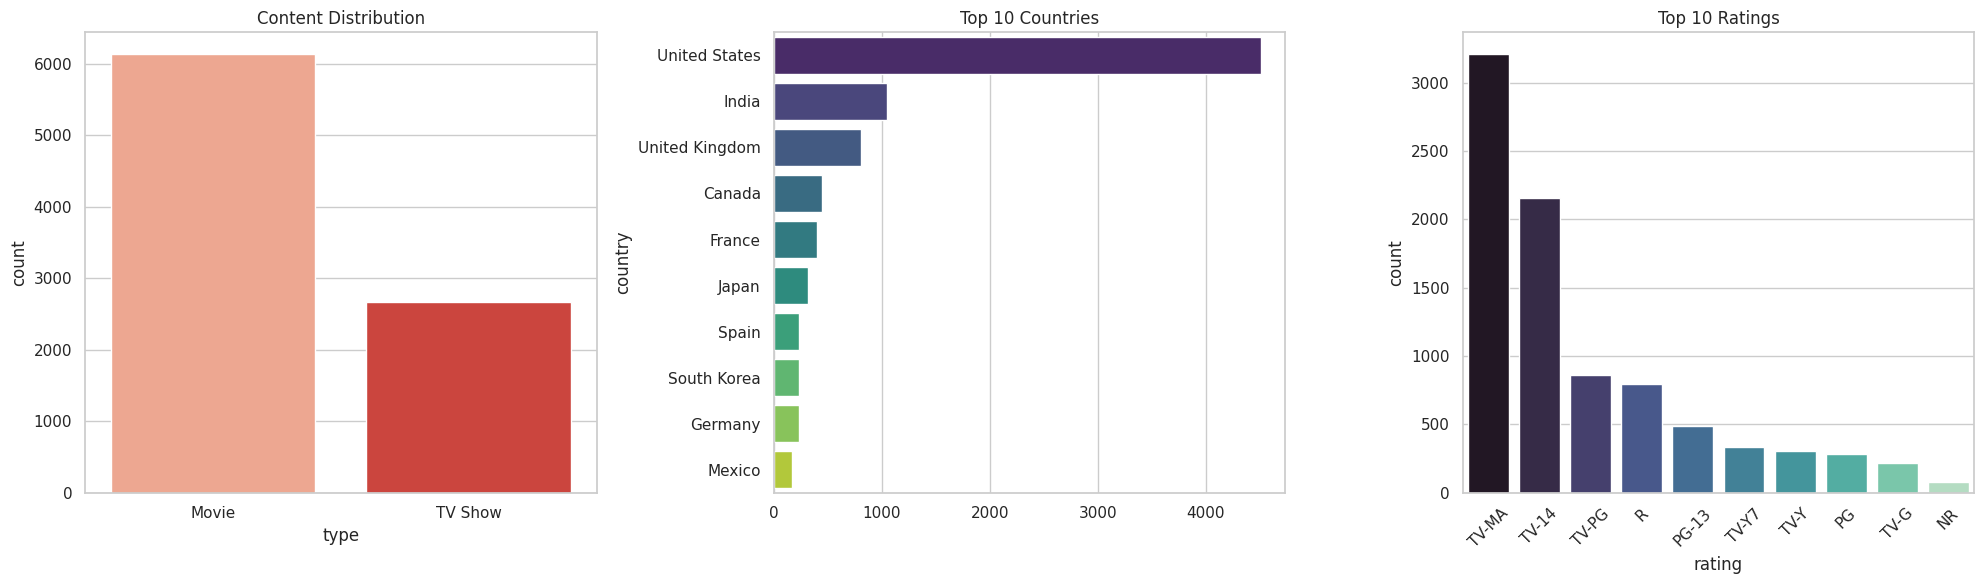

In [ ]:
# 2. Setup Plotting Style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Movies vs TV Shows
sns.countplot(data=df, x='type', ax=axes[0], palette='Reds')
axes[0].set_title('Content Distribution')

# Plot 2: Top 10 Countries
top_10 = df['country'].str.split(', ').explode().value_counts().head(10)
sns.barplot(x=top_10.values, y=top_10.index, ax=axes[1], palette='viridis')
axes[1].set_title('Top 10 Countries')

# Plot 3: Ratings Distribution
sns.countplot(data=df, x='rating', ax=axes[2], order=df['rating'].value_counts().index[:10], palette='mako')
axes[2].set_title('Top 10 Ratings')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

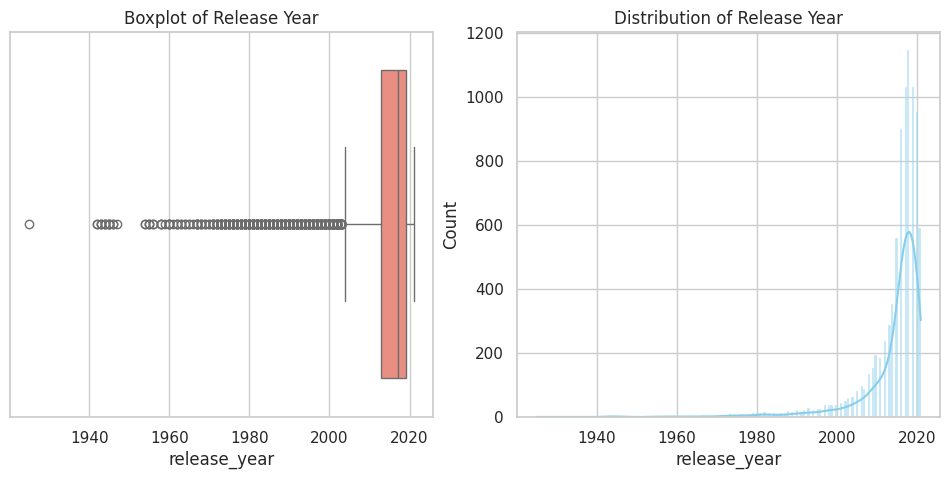

Skewness Score: -3.45
Result: Highly skewed data. Use MEDIAN for filling missing values.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a figure for outlier detection
plt.figure(figsize=(12, 5))

# Plot 1: Boxplot to visually identify outliers (dots outside the whiskers)
plt.subplot(1, 2, 1)
sns.boxplot(x=df['release_year'], color='salmon')
plt.title('Boxplot of Release Year')

# Plot 2: Histogram/KDE to check the distribution/skew
plt.subplot(1, 2, 2)
sns.histplot(df['release_year'], kde=True, color='skyblue')
plt.title('Distribution of Release Year')

plt.show()

# Statistical check for skewness
skew_val = df['release_year'].skew()
print(f"Skewness Score: {skew_val:.2f}")

if abs(skew_val) > 1:
    print("Result: Highly skewed data. Use MEDIAN for filling missing values.")
else:
    print("Result: Fairly symmetric data. MEAN can be used.")

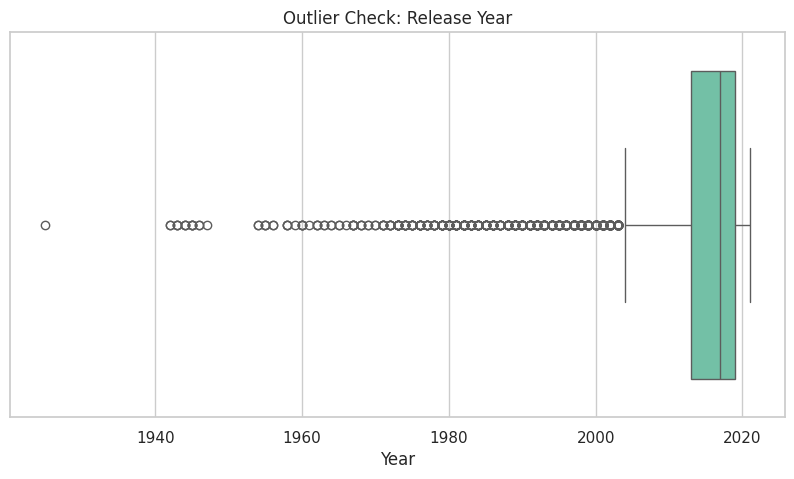

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# The single most effective plot for outlier detection
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['release_year'], color='mediumaquamarine')

plt.title('Outlier Check: Release Year')
plt.xlabel('Year')
plt.show()

In [ ]:
# Treating missing values by using the Median (Robust to outliers)
median_year = df['release_year'].median()
df['release_year'] = df['release_year'].fillna(median_year)

In [ ]:
# Capping outliers: setting a floor at the 5th percentile
floor = df['release_year'].quantile(0.05)
df['release_year'] = df['release_year'].clip(lower=floor)

In [ ]:
import numpy as np
# Applying log transformation to reduce the impact of outliers
df['release_year_log'] = np.log(df['release_year'])


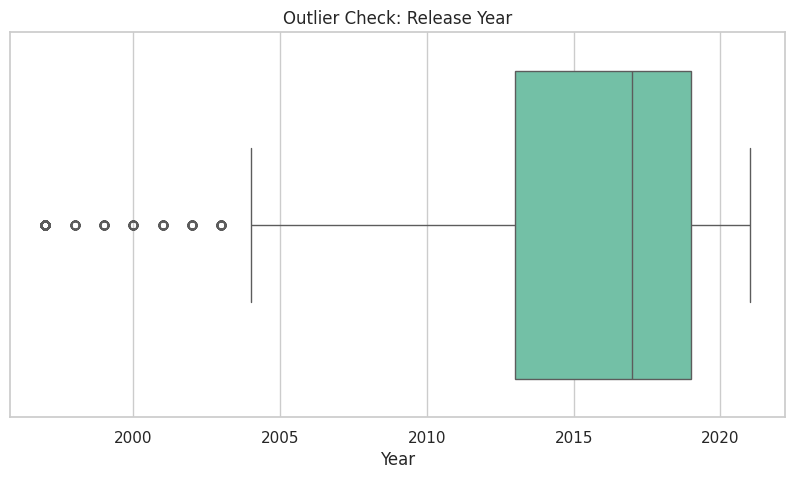

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# The single most effective plot for outlier detection
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['release_year'], color='mediumaquamarine')

plt.title('Outlier Check: Release Year')
plt.xlabel('Year')
plt.show()

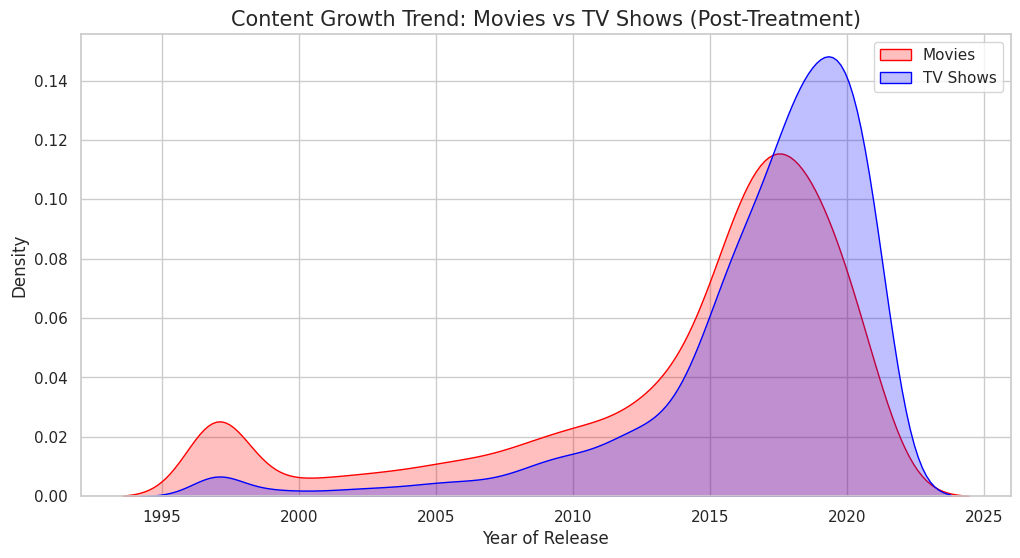

--- Average Release Year by Type ---
type
Movie      2016.0
TV Show    2018.0
Name: release_year, dtype: float64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Setup the figure
plt.figure(figsize=(12, 6))

# 2. Plotting the density of content over time
# We use a KDE plot to see the "flow" of when content was released
sns.kdeplot(data=df[df['type'] == 'Movie'], x='release_year', label='Movies', fill=True, color='red')
sns.kdeplot(data=df[df['type'] == 'TV Show'], x='release_year', label='TV Shows', fill=True, color='blue')

# 3. Formatting
plt.title('Content Growth Trend: Movies vs TV Shows (Post-Treatment)', fontsize=15)
plt.xlabel('Year of Release')
plt.ylabel('Density')
plt.legend()
plt.show()

# 4. Summary Statistics for the Batch
print("--- Average Release Year by Type ---")
print(df.groupby('type')['release_year'].median())

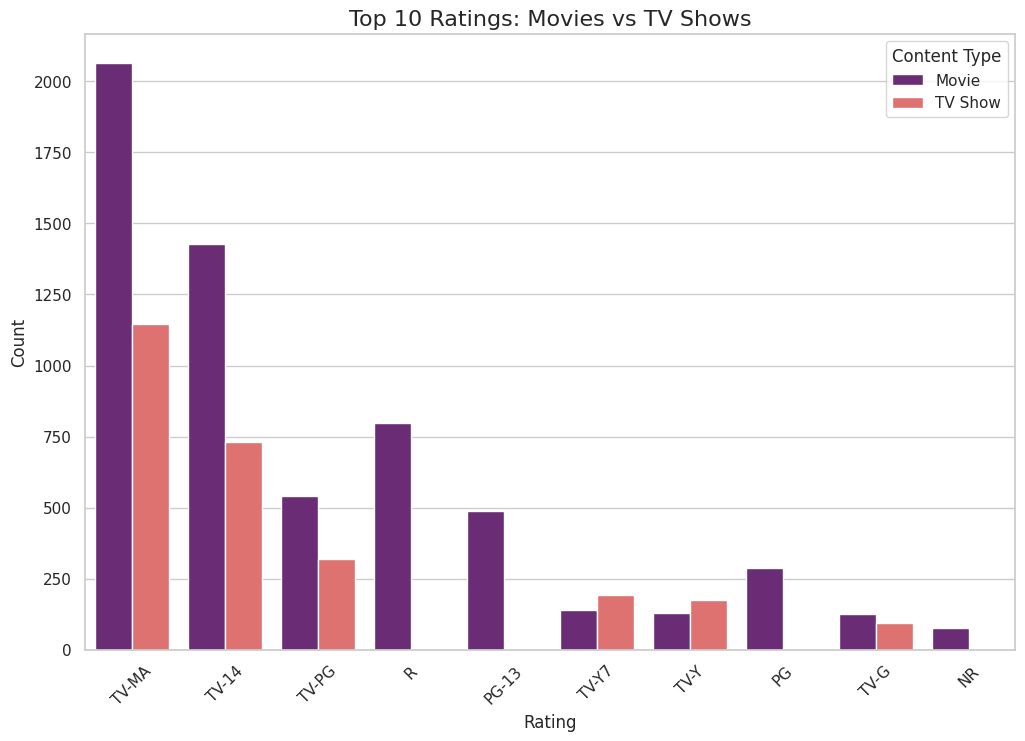

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare the data: Get the top 10 ratings to keep the chart clean
top_ratings = df['rating'].value_counts().index[:10]
df_top_ratings = df[df['rating'].isin(top_ratings)]

# 2. Create the plot
plt.figure(figsize=(12, 8))
sns.countplot(data=df_top_ratings, x='rating', hue='type', palette='magma',
              order=top_ratings)

# 3. Aesthetics
plt.title('Top 10 Ratings: Movies vs TV Shows', fontsize=16)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Content Type')
plt.xticks(rotation=45)
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

# 1. Label Encoding for 'type' (Since there are only 2 types)
le = LabelEncoder()
df['type_encoded'] = le.fit_transform(df['type'])
# Result: Movie = 0, TV Show = 1 (or vice versa)

# 2. One-Hot Encoding for 'rating'
# This creates separate columns for TV-MA, PG, etc.
rating_dummies = pd.get_dummies(df['rating'], prefix='rating')
df = pd.concat([df, rating_dummies], axis=1)

# 3. Clean up
# Now we can drop the original object columns if we are going to train a model
# df.drop(['type', 'rating'], axis=1, inplace=True)

print("--- Data Types After Conversion ---")
print(df[['type_encoded', 'rating_TV-MA']].dtypes)
df.head()


--- Data Types After Conversion ---
type_encoded    int64
rating_TV-MA     bool
dtype: object


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,rating_PG-13,rating_R,rating_TV-14,rating_TV-G,rating_TV-MA,rating_TV-PG,rating_TV-Y,rating_TV-Y7,rating_TV-Y7-FV,rating_UR
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown Cast,United States,2021-09-25,2020,PG-13,90 min,...,True,False,False,False,False,False,False,False,False,False
1,s2,TV Show,Blood & Water,Unknown Director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,...,False,False,False,False,True,False,False,False,False,False
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,1 Season,...,False,False,False,False,True,False,False,False,False,False
3,s4,TV Show,Jailbirds New Orleans,Unknown Director,Unknown Cast,United States,2021-09-24,2021,TV-MA,1 Season,...,False,False,False,False,True,False,False,False,False,False
4,s5,TV Show,Kota Factory,Unknown Director,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,...,False,False,False,False,True,False,False,False,False,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8797 entries, 0 to 8806
Data columns (total 31 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   show_id           8797 non-null   object        
 1   type              8797 non-null   object        
 2   title             8797 non-null   object        
 3   director          8797 non-null   object        
 4   cast              8797 non-null   object        
 5   country           8797 non-null   object        
 6   date_added        8797 non-null   datetime64[ns]
 7   release_year      8797 non-null   int64         
 8   rating            8797 non-null   object        
 9   duration          8797 non-null   object        
 10  listed_in         8797 non-null   object        
 11  description       8797 non-null   object        
 12  release_year_log  8797 non-null   float64       
 13  type_encoded      8797 non-null   int64         
 14  rating_66 min     8797 non-nu

In [ ]:
from sklearn.preprocessing import LabelEncoder

# 1. Identify all 'object' columns
object_cols = df.select_dtypes(include=['object']).columns

# 2. Initialize the LabelEncoder
le = LabelEncoder()

# 3. Loop through columns and convert to int
for col in object_cols:
    # We use .astype(str) to ensure any leftover nulls don't crash the encoder
    df[col] = le.fit_transform(df[col].astype(str))

# 4. Handle any remaining floats (like release_year_log or bools)
# This forces everything in the dataframe to int64
df = df.astype(int)

# Check the results
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 8797 entries, 0 to 8806
Data columns (total 31 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   show_id           8797 non-null   int64
 1   type              8797 non-null   int64
 2   title             8797 non-null   int64
 3   director          8797 non-null   int64
 4   cast              8797 non-null   int64
 5   country           8797 non-null   int64
 6   date_added        8797 non-null   int64
 7   release_year      8797 non-null   int64
 8   rating            8797 non-null   int64
 9   duration          8797 non-null   int64
 10  listed_in         8797 non-null   int64
 11  description       8797 non-null   int64
 12  release_year_log  8797 non-null   int64
 13  type_encoded      8797 non-null   int64
 14  rating_66 min     8797 non-null   int64
 15  rating_74 min     8797 non-null   int64
 16  rating_84 min     8797 non-null   int64
 17  rating_G          8797 non-null   int6

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,rating_PG-13,rating_R,rating_TV-14,rating_TV-G,rating_TV-MA,rating_TV-PG,rating_TV-Y,rating_TV-Y7,rating_TV-Y7-FV,rating_UR
0,0,0,1973,2295,7237,603,1632528000000000000,2020,7,210,...,1,0,0,0,0,0,0,0,0,0
1,1111,1,1089,4303,409,426,1632441600000000000,2021,11,110,...,0,0,0,0,1,0,0,0,0,0
2,2222,1,2647,2105,6287,603,1632441600000000000,2021,11,0,...,0,0,0,0,1,0,0,0,0,0
3,3333,1,3501,4303,7237,603,1632441600000000000,2021,11,0,...,0,0,0,0,1,0,0,0,0,0
4,4444,1,3855,4303,4806,251,1632441600000000000,2021,11,110,...,0,0,0,0,1,0,0,0,0,0


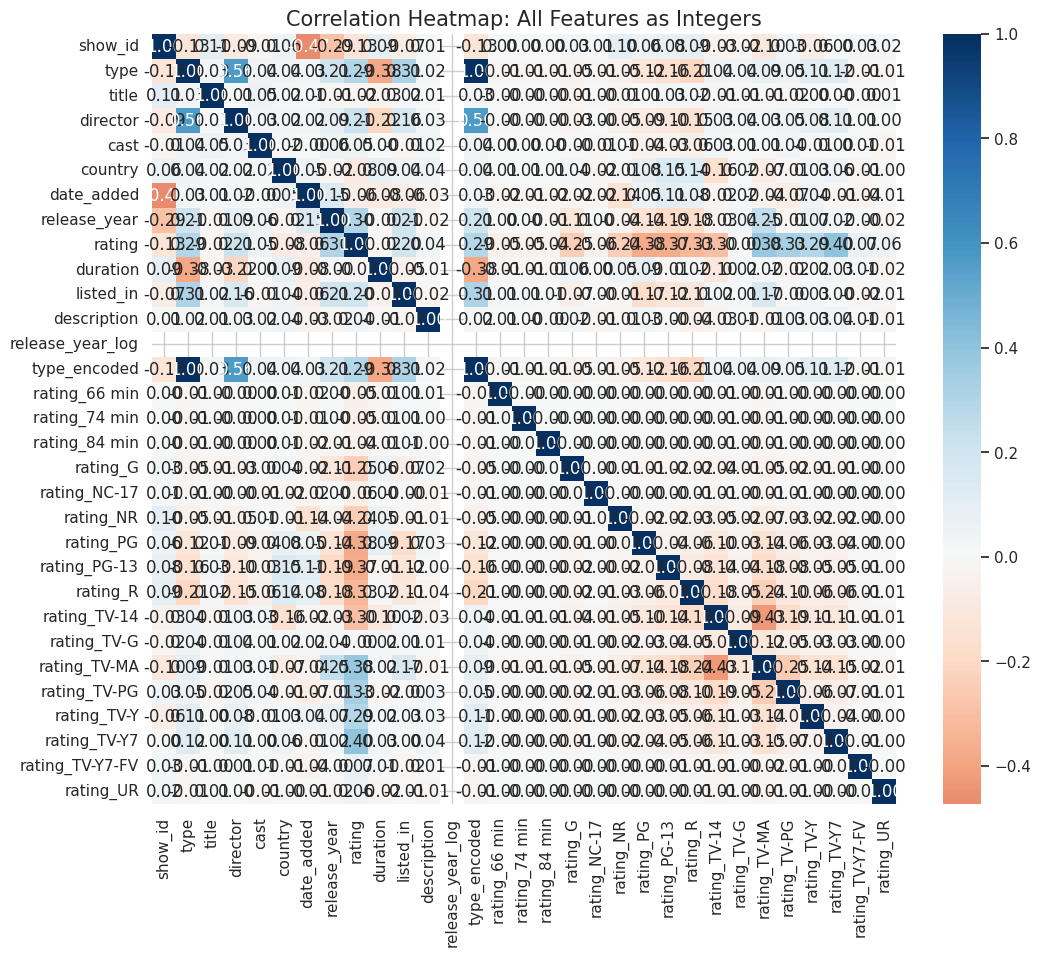

Top correlations with Content Type:
type                1.000000
type_encoded        1.000000
director            0.564442
listed_in           0.305635
rating              0.290720
release_year        0.210288
rating_TV-Y7        0.120641
rating_TV-Y         0.111048
rating_TV-MA        0.088630
rating_TV-PG        0.050000
rating_TV-14        0.043871
rating_TV-G         0.043287
country             0.042893
cast                0.039817
date_added          0.026959
title               0.026187
description         0.021178
rating_66 min      -0.007031
rating_74 min      -0.007031
rating_84 min      -0.007031
rating_TV-Y7-FV    -0.007753
rating_UR          -0.012180
rating_NC-17       -0.012180
rating_G           -0.045124
rating_NR          -0.052285
rating_PG          -0.121099
show_id            -0.127023
rating_PG-13       -0.160155
rating_R           -0.206702
duration           -0.381500
release_year_log         NaN
Name: type, dtype: float64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the correlation between all integer columns
corr = df.corr()

# 2. Plotting the Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='RdBu', center=0)
plt.title('Correlation Heatmap: All Features as Integers', fontsize=15)
plt.show()

# 3. Quick insight: Find the most correlated features with 'type'
print("Top correlations with Content Type:")
print(corr['type'].sort_values(ascending=False))

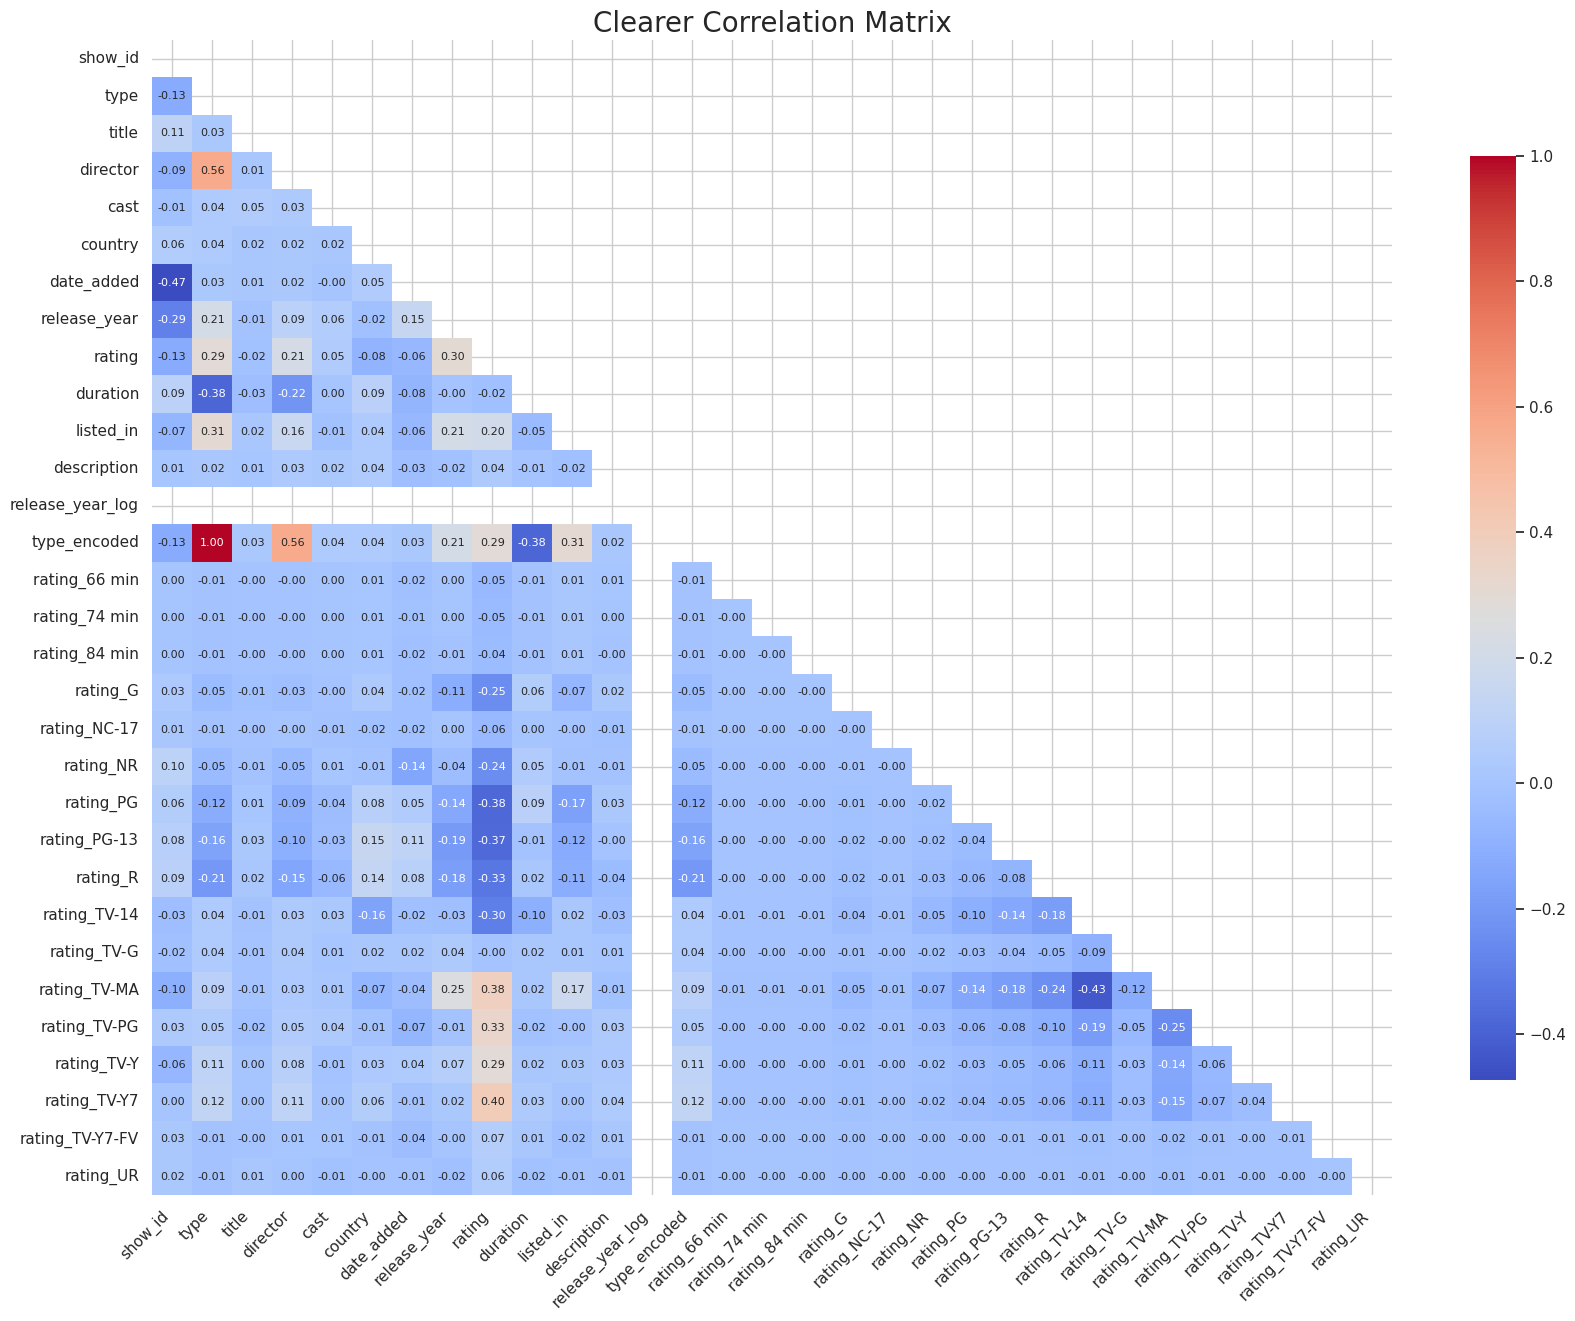

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Increase figure size significantly
plt.figure(figsize=(20, 15))

# 2. Focus on the most important correlations
# (Filtering out values near 0 to reduce noise)
corr = df.corr()

# 3. Create a mask to hide the top half (it's a mirror image anyway)
import numpy as np
mask = np.triu(np.ones_like(corr, dtype=bool))

# 4. Plot with better formatting
sns.heatmap(corr,
            mask=mask,
            annot=True,          # Show the numbers
            fmt=".2f",           # Keep 2 decimal places
            cmap='coolwarm',     # Red for positive, Blue for negative
            annot_kws={"size": 8}, # Make numbers smaller so they fit
            cbar_kws={"shrink": .8})

plt.title('Clearer Correlation Matrix', fontsize=20)
plt.xticks(rotation=45, ha='right') # Rotate labels so they don't overlap
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Define the Target (y) - what we want to predict (e.g., Content Type)
# and the Features (X) - the data we use to make the prediction
y = df['type']
X = df.drop(['type', 'show_id'], axis=1) # Drop target and unique ID

# 2. Split the data
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Verify the shapes
print(f"Total rows: {len(df)}")
print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Total rows: 8797
Training set size: 7037
Testing set size: 1760
